In [1]:
sys.path.append("../dataloaders")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from data_loader_cropping_padding import CroppedPaddedDataset
from data_loader_cropping_nopadding import CroppedDataset
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import sys
import torch.nn.functional as F
import numpy as np
from scipy.signal import find_peaks

## Load dataset

In [3]:

#Dataset with padding
dataset = CroppedPaddedDataset("../annot_crops.csv", "../SplitImages")

#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Image width 400 and height 200
Found 328 valid samples


## ResNet Model

In [4]:
class ResNetRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # regression-head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)


        #Freeze First layers
        for p in self.backbone.conv1.parameters():
            p.requires_grad = False
        for p in self.backbone.bn1.parameters():
            p.requires_grad = False
        for p in self.backbone.layer1.parameters():
            p.requires_grad = False
        for p in self.backbone.layer2.parameters():
            p.requires_grad = False
        for p in self.backbone.layer3.parameters():
            p.requires_grad = False
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True
        for p in self.backbone.fc.parameters():
            p.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

model_ResNet = ResNetRegressor().to(device)

In [5]:
# Training, validation and test-data
val_split = 0.2   # 20% val
test_split = 0.1  # 10% test 

n_total = len(dataset)
n_test = int(n_total * test_split)
n_val = int(n_total * val_split)
n_train = n_total - n_val - n_test

#Seed
generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


Train: 231, Val: 65, Test: 32


In [6]:
criterion = nn.SmoothL1Loss(beta=1.0)  #Huber-loss

optimizer = optim.Adam(model_ResNet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
num_epochs = 25

train_mse_list = []
val_mse_list = []
val_mae_list = []

## Training and validation

In [7]:
model_ResNet.train()

for epoch in range(num_epochs):
    #Train
    model_ResNet.train()
    running_mse = 0.0
    n_train = 0

    for imgs, labels, names in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().view(-1, 1).to(device)

        optimizer.zero_grad()
        outputs = model_ResNet(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        mse_batch = torch.mean((outputs - labels)**2).item()
        running_mse += mse_batch * imgs.size(0)
        n_train += imgs.size(0)

    train_mse_epoch = running_mse / n_train
    train_mse_list.append(train_mse_epoch)

    #Validation
    model_ResNet.eval()
    val_mse = 0.0
    val_mae = 0.0
    n_val = 0

    with torch.no_grad():
        for imgs, labels, names in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().view(-1, 1).to(device)

            outputs = model_ResNet(imgs)
            mse_batch = torch.mean((outputs - labels)**2).item()
            mae_batch = torch.mean(torch.abs(outputs - labels)).item()

            val_mse += mse_batch * imgs.size(0)
            val_mae += mae_batch * imgs.size(0)
            n_val += imgs.size(0)

    val_mse_epoch = val_mse / n_val
    val_mae_epoch = val_mae / n_val

    val_mse_list.append(val_mse_epoch)
    val_mae_list.append(val_mae_epoch)

    scheduler.step(val_mae_epoch)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train MSE: {train_mse_epoch:.3f} - "
          f"Val MSE: {val_mse_epoch:.3f} - "
          f"Val MAE: {val_mae_epoch:.3f}")

Epoch 1/25 - Train MSE: 52.353 - Val MSE: 45.617 - Val MAE: 3.714
Epoch 2/25 - Train MSE: 36.329 - Val MSE: 27.670 - Val MAE: 2.416
Epoch 3/25 - Train MSE: 29.804 - Val MSE: 23.342 - Val MAE: 2.135
Epoch 4/25 - Train MSE: 21.864 - Val MSE: 16.717 - Val MAE: 1.898
Epoch 5/25 - Train MSE: 18.844 - Val MSE: 10.065 - Val MAE: 1.722
Epoch 6/25 - Train MSE: 16.998 - Val MSE: 9.873 - Val MAE: 1.668
Epoch 7/25 - Train MSE: 14.803 - Val MSE: 8.797 - Val MAE: 1.976
Epoch 8/25 - Train MSE: 14.711 - Val MSE: 10.773 - Val MAE: 1.672
Epoch 9/25 - Train MSE: 14.947 - Val MSE: 12.038 - Val MAE: 1.701
Epoch 10/25 - Train MSE: 15.202 - Val MSE: 10.474 - Val MAE: 1.892
Epoch 11/25 - Train MSE: 20.076 - Val MSE: 10.329 - Val MAE: 1.760
Epoch 12/25 - Train MSE: 12.032 - Val MSE: 10.121 - Val MAE: 1.722
Epoch 13/25 - Train MSE: 12.047 - Val MSE: 8.672 - Val MAE: 1.558
Epoch 14/25 - Train MSE: 12.975 - Val MSE: 8.242 - Val MAE: 1.533
Epoch 15/25 - Train MSE: 12.607 - Val MSE: 9.037 - Val MAE: 1.538
Epoch 16/

## Plot training and validation

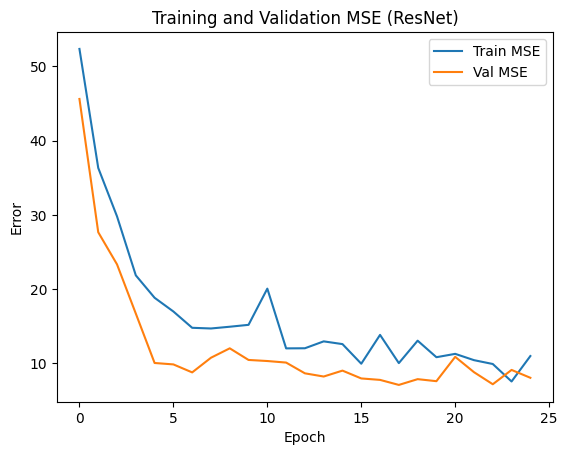

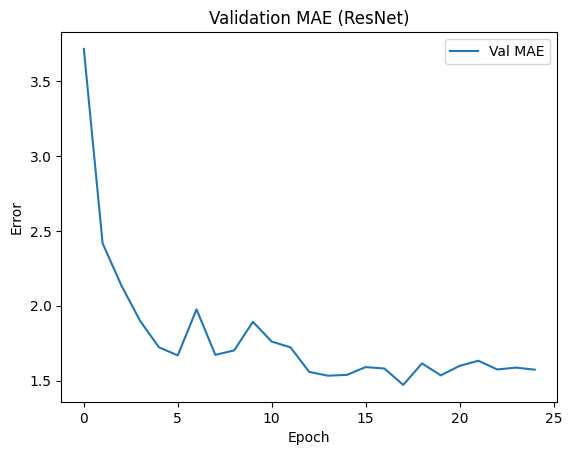

In [8]:
#MSE
plt.figure()
plt.plot(train_mse_list, label="Train MSE")
plt.plot(val_mse_list, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Training and Validation MSE (ResNet)")
plt.legend()
plt.show()

#MAE
plt.figure()
plt.plot(val_mae_list, label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Validation MAE (ResNet)")
plt.legend()
plt.show()

## Save model

In [9]:
#Save trained model
model_path = "resnet_regressor_final.pth"
torch.save(model_ResNet.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: resnet_regressor_final.pth


In [10]:
model_ResNet = ResNetRegressor().to(device)
state_dict = torch.load("resnet_regressor_final.pth", map_location=device)
model_ResNet.load_state_dict(state_dict)
model_ResNet.eval()

C:\Users\norae\AppData\Local\Temp\ipykernel_26484\1559016043.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet_regressor_final.pth", map_lo

ResNetRegressor(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [11]:
test_mae = 0.0
n_test = 0

with torch.no_grad():
    for imgs, labels, names in test_loader:
        imgs = imgs.to(device)
        labels = labels.float().view(-1, 1).to(device)

        outputs = model_ResNet(imgs)

        mae_batch = torch.mean(torch.abs(outputs - labels)).item()
        test_mae += mae_batch * imgs.size(0)
        n_test += imgs.size(0)

test_mae /= n_test

print(f"Test MAE: {test_mae:.3f}")


Test MAE: 1.450
